In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer,LabelEncoder
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    roc_auc_score, f1_score)
from xgboost import XGBRegressor,XGBClassifier
from sklearn.linear_model import Perceptron
from sklearn.linear_model import LogisticRegression
import pickle
import os

In [3]:
path_file = "creditcard.csv"
credit_df = pd.read_csv(path_file)
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
credit_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
credit_df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

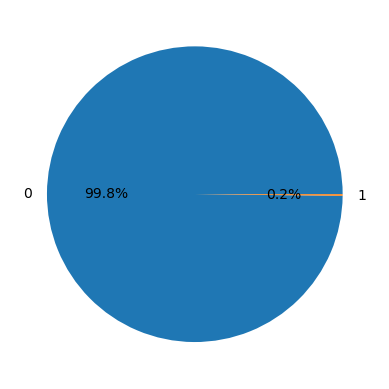

In [7]:
credit_df["Class"].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

In [27]:
credit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
print(f"Fraud: {credit_df['Class'].mean()*100:.3f}%")

Fraud: 0.173%


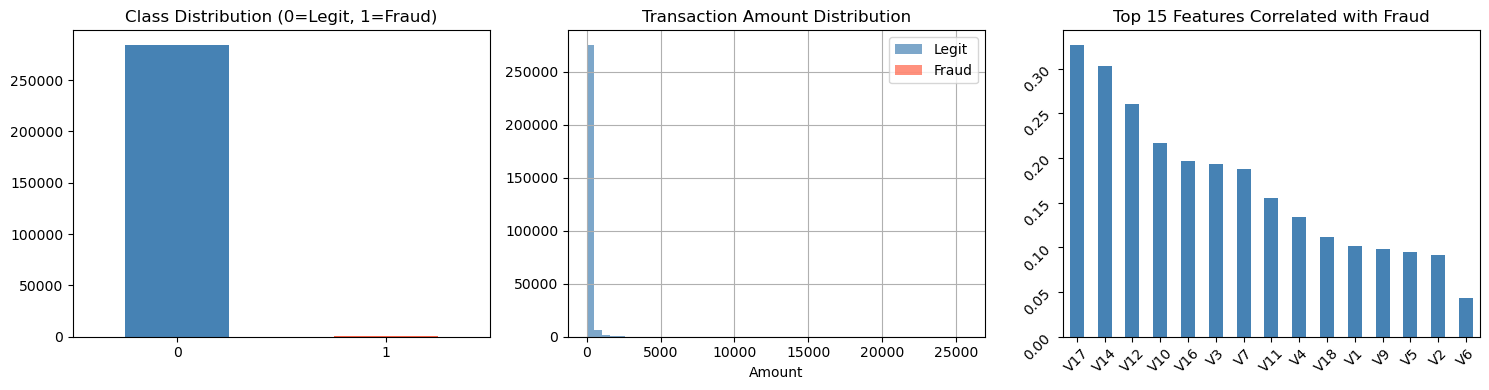

EDA plots saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
# Class distribution
credit_df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution (0=Legit, 1=Fraud)')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)
 
# Amount distribution by class
credit_df[credit_df['Class']==0]['Amount'].hist(ax=axes[1], bins=50, alpha=0.7, label='Legit', color='steelblue')
credit_df[credit_df['Class']==1]['Amount'].hist(ax=axes[1], bins=50, alpha=0.7, label='Fraud', color='tomato')
axes[1].set_title('Transaction Amount Distribution')
axes[1].legend()
axes[1].set_xlabel('Amount')

# Correlation of V features with Class
corr = credit_df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(15)
corr.plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Top 15 Features Correlated with Fraud')
axes[2].tick_params(rotation=45)
 
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved.")

In [10]:
credit_df["Time"]

0              0.0
1              0.0
2              1.0
3              1.0
4              2.0
            ...   
284802    172786.0
284803    172787.0
284804    172788.0
284805    172788.0
284806    172792.0
Name: Time, Length: 284807, dtype: float64

In [11]:
X = credit_df.drop('Class', axis=1)   
y = credit_df['Class']
 
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")


Feature matrix shape: (284807, 30)
Target shape: (284807,)


In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

In [14]:
print(f"\nTrain fraud count: {y_train.sum()} / {len(y_train)}")
print(f"Test fraud count:  {y_test.sum()} / {len(y_test)}")


Train fraud count: 394 / 227845
Test fraud count:  98 / 56962


In [63]:
scale_cols = X.select_dtypes(include="number").columns.tolist()
scale_cols

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scale',StandardScaler(), scale_cols)     
    ],
    remainder='drop'   
)

In [ ]:
# Each pipeline = preprocessor → (optional SMOTE) → model
# ImbPipeline from imbalanced-learn supports SMOTE as a step
# sklearn Pipeline does NOT support SMOTE always use ImbPipeline when SMOTE needed
 
# Logistic Regression Pipeline 
lr_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        C=0.01,
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])
# No SMOTE here class_weight='balanced' handles imbalance internally
 
#  Random Forest Pipeline (with SMOTE)
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])
 
# XGBoost Pipeline (scale_pos_weight instead of SMOTE)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pw  = neg_count / pos_count
print(f"\nXGBoost scale_pos_weight: {scale_pw:.1f}")
 
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pw,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ))
])


XGBoost scale_pos_weight: 577.3


In [66]:
pipelines = {
    'Logistic Regression': lr_pipeline,
    'Random Forest':       rf_pipeline,
    'XGBoost':             xgb_pipeline,
}


  Training: Logistic Regression
  AUPRC : 0.7160  ← main metric
  AUROC : 0.9722
  F1    : 0.1159
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


  Training: Random Forest
  AUPRC : 0.8317  ← main metric
  AUROC : 0.9808
  F1    : 0.5676
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.42      0.86      0.57        98

    accuracy                           1.00     56962
   macro avg       0.71      0.93      0.78     56962
weighted avg       1.00      1.00      1.00     56962


  Training: XGBoost
  AUPRC : 0.8775  ← main metric
  AUROC : 0.9802
  F1    : 0.8438
              precision    recall  f1-score   support

       Legit

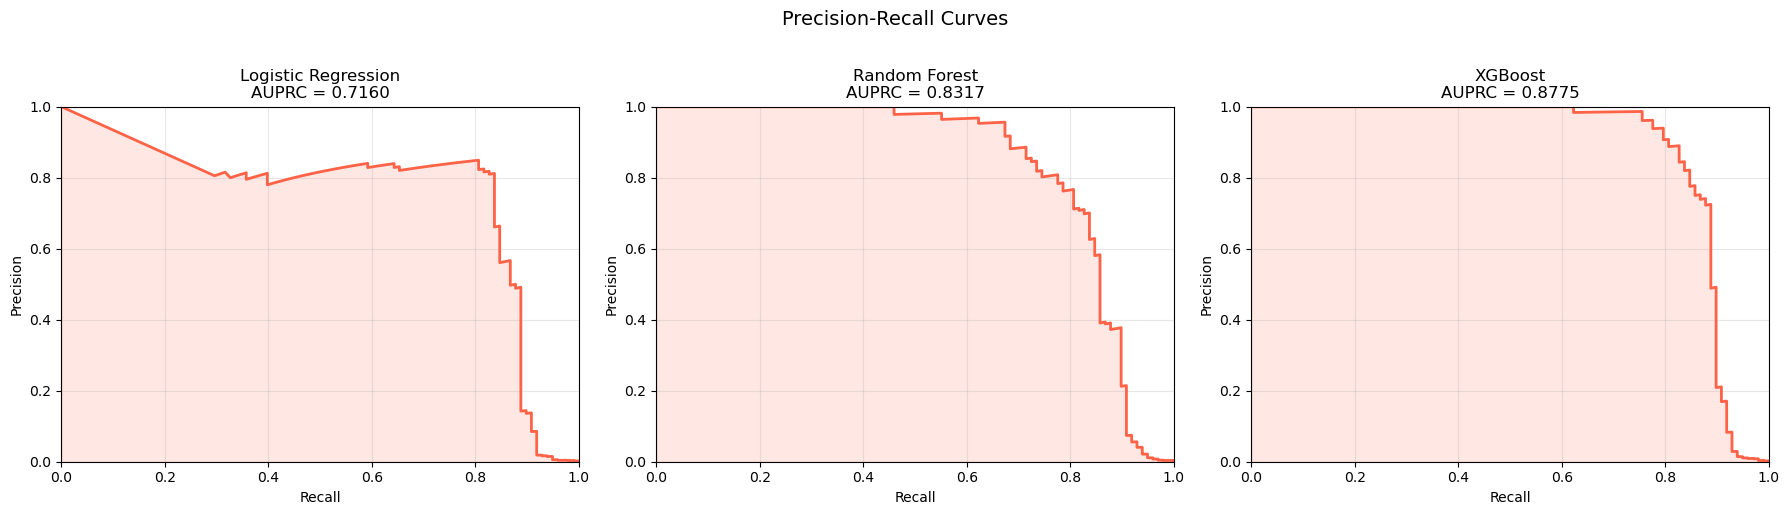

In [ ]:
results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
for i, (name, pipe) in enumerate(pipelines.items()):
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print(f"{'='*50}")
 
    # .fit() on raw X_train pipeline handles scaling internally
    pipe.fit(X_train, y_train)
 
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
 
    auprc = average_precision_score(y_test, y_proba)
    auroc = roc_auc_score(y_test, y_proba)
    f1    = f1_score(y_test, y_pred)
 
    results[name] = {
        'AUPRC': auprc, 'AUROC': auroc, 'F1': f1,
        'pipe': pipe, 'proba': y_proba, 'pred': y_pred
    }
 
    print(f"  AUPRC : {auprc:.4f}  ← main metric")
    print(f"  AUROC : {auroc:.4f}")
    print(f"  F1    : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Legit','Fraud']))
 
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[i].plot(rec, prec, lw=2, color='tomato')
    axes[i].fill_between(rec, prec, alpha=0.15, color='tomato')
    axes[i].set_title(f'{name}\nAUPRC = {auprc:.4f}')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_xlim([0,1]); axes[i].set_ylim([0,1])
    axes[i].grid(True, alpha=0.3)
 
plt.suptitle('Precision-Recall Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
print("\n" + "="*55)
print("  MODEL COMPARISON")
print("="*55)
results_df = pd.DataFrame({
    name: {'AUPRC': v['AUPRC'], 'AUROC': v['AUROC'], 'F1': v['F1']}
    for name, v in results.items()
}).T.round(4)
print(results_df.to_string())
 
best_name = results_df['AUPRC'].idxmax()
print(f"\n★ Best model: {best_name}")


  MODEL COMPARISON
                      AUPRC   AUROC      F1
Logistic Regression  0.7160  0.9722  0.1159
Random Forest        0.8317  0.9808  0.5676
XGBoost              0.8775  0.9802  0.8438

★ Best model: XGBoost


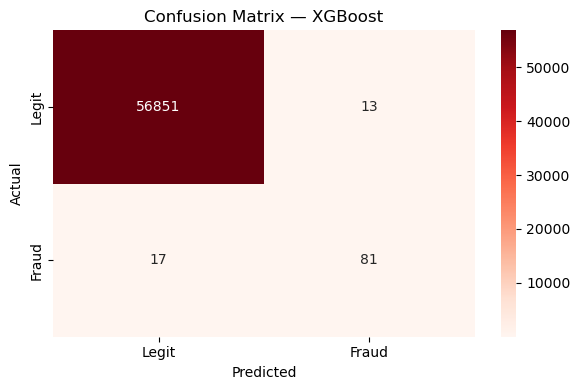

In [69]:
best = results[best_name]
cm   = confusion_matrix(y_test, best['pred'])
 
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

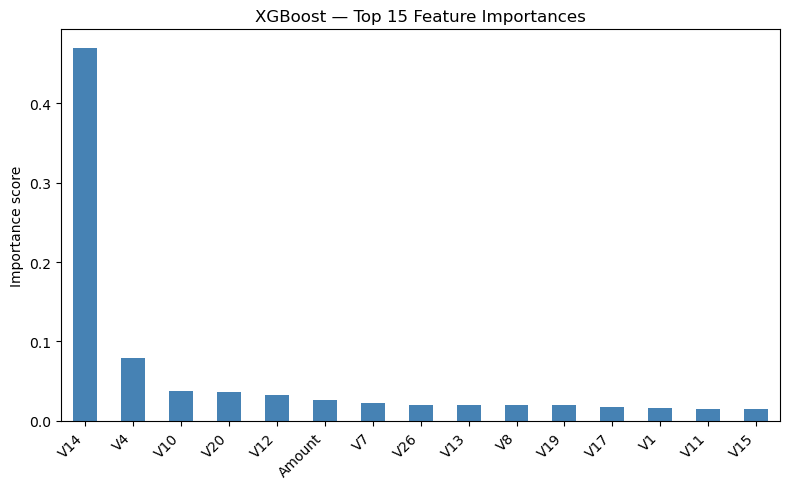


Top 5 features:
V14    0.469881
V4     0.079336
V10    0.038154
V20    0.036278
V12    0.033029
dtype: float32


In [73]:
if 'XGBoost' in results:
    xgb_model = results['XGBoost']['pipe'].named_steps['model']
    ct = results['XGBoost']['pipe'].named_steps['preprocessor']
    
    # Get feature names from the fitted ColumnTransformer
    feat_names = ct.get_feature_names_out()
    
    # Optional: remove the transformer prefix for cleaner display
    feat_names_clean = [name.split('__', 1)[-1] for name in feat_names]
    
    feat_imp = pd.Series(
        xgb_model.feature_importances_, 
        index=feat_names_clean
    ).sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(8, 5))
    feat_imp.plot(kind='bar', color='steelblue')
    plt.title('XGBoost — Top 15 Feature Importances')
    plt.ylabel('Importance score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nTop 5 features:")
    print(feat_imp.head())

In [74]:
import pickle
import os

# model/ folder banao agar nahi hai
os.makedirs("model", exist_ok=True)

# Best model save karo (jo bhi AUPRC mein winner tha)
model_path = "model/best_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(results[best_name]['pipe'], f)

print(f"✅ Model saved: {model_path}")
print(f"   Model name : {best_name}")

✅ Model saved: model/best_model.pkl
   Model name : XGBoost


In [75]:
# Load karke test karo
with open("model/best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Ek test prediction karo
test_sample = X_test.iloc[:3]
preds  = loaded_model.predict(test_sample)
probas = loaded_model.predict_proba(test_sample)[:, 1]

print("🔍 Test Predictions:")
for i, (pred, prob) in enumerate(zip(preds, probas)):
    label = "🚨 FRAUD" if pred == 1 else "✅ Legit"
    print(f"   Row {i+1}: {label}  (fraud probability: {prob:.4f})")

print("\n✅ Model successfully loaded and working!")

🔍 Test Predictions:
   Row 1: ✅ Legit  (fraud probability: 0.0000)
   Row 2: ✅ Legit  (fraud probability: 0.0000)
   Row 3: ✅ Legit  (fraud probability: 0.0001)

✅ Model successfully loaded and working!
